<a href="https://colab.research.google.com/github/abdullahfayed6/Hands-On/blob/main/SketchRNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import tensorflow as tf
from tensorflow import keras
from keras import layers , models , optimizers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [9]:
tf_download_root = "http://download.tensorflow.org/data/"
filename = "quickdraw_tutorial_dataset_v1.tar.gz"
filepath = tf.keras.utils.get_file(filename,
                                   tf_download_root + filename,
                                   cache_dir=".",
                                   extract=True)

1065301781/1065301781 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [12]:
if "_extracted" in filepath:
    quickdraw_dir = Path(filepath)
else:
    quickdraw_dir = Path(filepath).parent
train_files = sorted(
    [str(path) for path in quickdraw_dir.glob("training.tfrecord-*")]
)
eval_files = sorted(
    [str(path) for path in quickdraw_dir.glob("eval.tfrecord-*")]
)

In [13]:
train_files


['datasets/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00000-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00001-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00002-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00003-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00004-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00005-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00006-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00007-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00008-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/training.tfrecord-00009-of-00010']

In [14]:
eval_files


['datasets/quickdraw_tutorial_dataset_v1_extracted/eval.tfrecord-00000-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/eval.tfrecord-00001-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/eval.tfrecord-00002-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/eval.tfrecord-00003-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/eval.tfrecord-00004-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/eval.tfrecord-00005-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/eval.tfrecord-00006-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/eval.tfrecord-00007-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/eval.tfrecord-00008-of-00010',
 'datasets/quickdraw_tutorial_dataset_v1_extracted/eval.tfrecord-00009-of-00010']

In [15]:
with open(quickdraw_dir / "eval.tfrecord.classes") as test_classes_file:
    test_classes = test_classes_file.readlines()

with open(quickdraw_dir / "training.tfrecord.classes") as train_classes_file:
    train_classes = train_classes_file.readlines()

In [16]:
assert train_classes == test_classes
class_names = [name.strip().lower() for name in train_classes]

In [17]:
sorted(class_names)

['aircraft carrier',
 'airplane',
 'alarm clock',
 'ambulance',
 'angel',
 'animal migration',
 'ant',
 'anvil',
 'apple',
 'arm',
 'asparagus',
 'axe',
 'backpack',
 'banana',
 'bandage',
 'barn',
 'baseball',
 'baseball bat',
 'basket',
 'basketball',
 'bat',
 'bathtub',
 'beach',
 'bear',
 'beard',
 'bed',
 'bee',
 'belt',
 'bench',
 'bicycle',
 'binoculars',
 'bird',
 'birthday cake',
 'blackberry',
 'blueberry',
 'book',
 'boomerang',
 'bottlecap',
 'bowtie',
 'bracelet',
 'brain',
 'bread',
 'bridge',
 'broccoli',
 'broom',
 'bucket',
 'bulldozer',
 'bus',
 'bush',
 'butterfly',
 'cactus',
 'cake',
 'calculator',
 'calendar',
 'camel',
 'camera',
 'camouflage',
 'campfire',
 'candle',
 'cannon',
 'canoe',
 'car',
 'carrot',
 'castle',
 'cat',
 'ceiling fan',
 'cell phone',
 'cello',
 'chair',
 'chandelier',
 'church',
 'circle',
 'clarinet',
 'clock',
 'cloud',
 'coffee cup',
 'compass',
 'computer',
 'cookie',
 'cooler',
 'couch',
 'cow',
 'crab',
 'crayon',
 'crocodile',
 'crow

In [18]:
def parse(data_batch):
    feature_descriptions = {
        "ink": tf.io.VarLenFeature(dtype=tf.float32),
        "shape": tf.io.FixedLenFeature([2], dtype=tf.int64),
        "class_index": tf.io.FixedLenFeature([1], dtype=tf.int64)
    }
    examples = tf.io.parse_example(data_batch, feature_descriptions)
    flat_sketches = tf.sparse.to_dense(examples["ink"])
    sketches = tf.reshape(flat_sketches, shape=[tf.size(data_batch), -1, 3])
    lengths = examples["shape"][:, 0]
    labels = examples["class_index"][:, 0]
    return sketches, lengths, labels

In [19]:
def quickdraw_dataset(filepaths, batch_size=32, shuffle_buffer_size=None,
                      n_parse_threads=5, n_read_threads=5, cache=False):
    dataset = tf.data.TFRecordDataset(filepaths,
                                      num_parallel_reads=n_read_threads)
    if cache:
        dataset = dataset.cache()
    if shuffle_buffer_size:
        dataset = dataset.shuffle(shuffle_buffer_size)
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(parse, num_parallel_calls=n_parse_threads)
    return dataset.prefetch(1)

In [20]:
train_set = quickdraw_dataset(train_files, shuffle_buffer_size=10000)
valid_set = quickdraw_dataset(eval_files[:5])
test_set = quickdraw_dataset(eval_files[5:])

In [21]:
for sketches, lengths, labels in train_set.take(1):
    print("sketches =", sketches)
    print("lengths =", lengths)
    print("labels =", labels)

sketches = tf.Tensor(
[[[-0.04700854  0.01568628  0.        ]
  [-0.01282051  0.06274509  0.        ]
  [ 0.00854701  0.08235294  0.        ]
  ...
  [ 0.          0.          0.        ]
  [ 0.          0.          0.        ]
  [ 0.          0.          0.        ]]

 [[-0.09502262 -0.03543305  0.        ]
  [-0.09049775 -0.05118114  0.        ]
  [-0.04977376 -0.06692913  0.        ]
  ...
  [ 0.          0.          0.        ]
  [ 0.          0.          0.        ]
  [ 0.          0.          0.        ]]

 [[-0.01449275  0.96862745  0.        ]
  [ 0.12560387 -0.06274509  0.        ]
  [ 0.32850242 -0.04313725  0.        ]
  ...
  [ 0.          0.          0.        ]
  [ 0.          0.          0.        ]
  [ 0.          0.          0.        ]]

 ...

 [[-0.08235294  0.012       0.        ]
  [-0.18823531  0.068       0.        ]
  [-0.1764706   0.096       0.        ]
  ...
  [ 0.          0.          0.        ]
  [ 0.          0.          0.        ]
  [ 0.          0.    

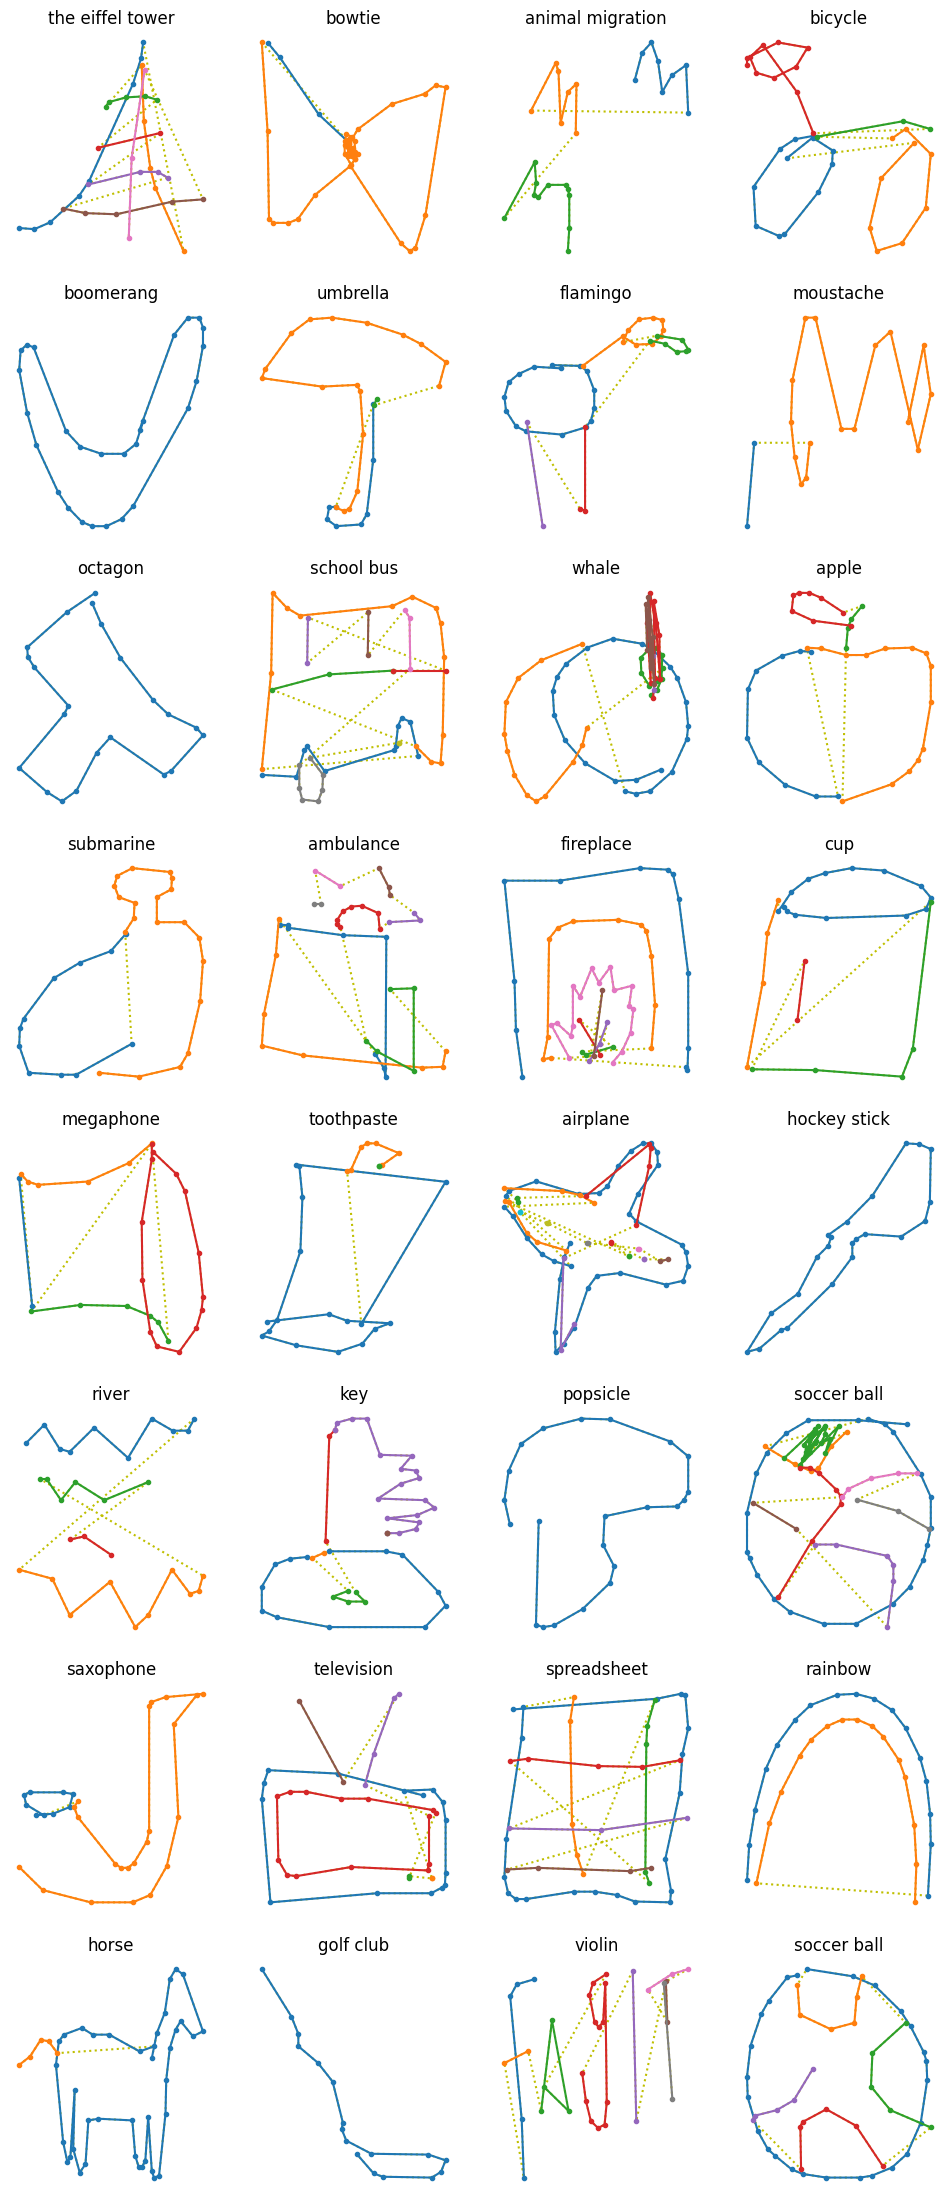

In [22]:
def draw_sketch(sketch, label=None):
    origin = np.array([[0., 0., 0.]])
    sketch = np.r_[origin, sketch]
    stroke_end_indices = np.argwhere(sketch[:, -1]==1.)[:, 0]
    coordinates = sketch[:, :2].cumsum(axis=0)
    strokes = np.split(coordinates, stroke_end_indices + 1)
    title = class_names[label.numpy()] if label is not None else "Try to guess"
    plt.title(title)
    plt.plot(coordinates[:, 0], -coordinates[:, 1], "y:")
    for stroke in strokes:
        plt.plot(stroke[:, 0], -stroke[:, 1], ".-")
    plt.axis("off")

def draw_sketches(sketches, lengths, labels):
    n_sketches = len(sketches)
    n_cols = 4
    n_rows = (n_sketches - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 3, n_rows * 3.5))
    for index, sketch, length, label in zip(range(n_sketches), sketches, lengths, labels):
        plt.subplot(n_rows, n_cols, index + 1)
        draw_sketch(sketch[:length], label)
    plt.show()

for sketches, lengths, labels in train_set.take(1):
    draw_sketches(sketches, lengths, labels)

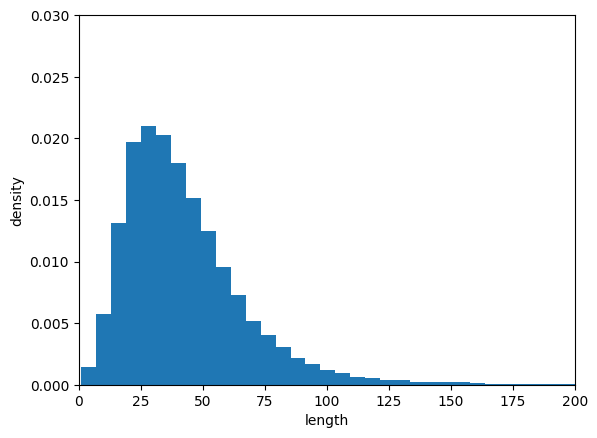

In [23]:
lengths = np.concatenate([lengths for _, lengths, _ in train_set.take(1000)])
plt.hist(lengths, bins=150, density=True)
plt.axis([0, 200, 0, 0.03])
plt.xlabel("length")
plt.ylabel("density")
plt.show()

In [24]:
def crop_long_sketches(dataset, max_length=100):
    return dataset.map(lambda inks, lengths, labels: (inks[:, :max_length], labels))

cropped_train_set = crop_long_sketches(train_set)
cropped_valid_set = crop_long_sketches(valid_set)
cropped_test_set = crop_long_sketches(test_set)

In [29]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(32, kernel_size=5, strides=2, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv1D(64, kernel_size=5, strides=2, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv1D(128, kernel_size=3, strides=2, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-2, clipnorm=1.)

model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy", "sparse_top_k_categorical_accuracy"])

history = model.fit(cropped_train_set, epochs=3,
                    validation_data=cropped_valid_set)

Epoch 1/3
 107812/Unknown 1033s 10ms/step - accuracy: 0.0817 - loss: 4.8377 - sparse_top_k_categorical_accuracy: 0.2086

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


107813/107813 ━━━━━━━━━━━━━━━━━━━━ 1060s 10ms/step - accuracy: 0.1693 - loss: 4.0839 - sparse_top_k_categorical_accuracy: 0.3741 - val_accuracy: 0.2964 - val_loss: 3.1502 - val_sparse_top_k_categorical_accuracy: 0.5795
Epoch 2/3
107813/107813 ━━━━━━━━━━━━━━━━━━━━ 1069s 10ms/step - accuracy: 0.3799 - loss: 2.7032 - sparse_top_k_categorical_accuracy: 0.6694 - val_accuracy: 0.4228 - val_loss: 2.4691 - val_sparse_top_k_categorical_accuracy: 0.7121
Epoch 3/3
107813/107813 ━━━━━━━━━━━━━━━━━━━━ 1058s 10ms/step - accuracy: 0.4521 - loss: 2.3260 - sparse_top_k_categorical_accuracy: 0.7385 - val_accuracy: 0.4675 - val_loss: 2.2452 - val_sparse_top_k_categorical_accuracy: 0.7523


In [30]:
history = model.fit(cropped_train_set, epochs=2,
                    validation_data=cropped_valid_set)

Epoch 1/2
107813/107813 ━━━━━━━━━━━━━━━━━━━━ 1058s 10ms/step - accuracy: 0.4905 - loss: 2.1338 - sparse_top_k_categorical_accuracy: 0.7711 - val_accuracy: 0.5009 - val_loss: 2.0830 - val_sparse_top_k_categorical_accuracy: 0.7785
Epoch 2/2
107813/107813 ━━━━━━━━━━━━━━━━━━━━ 1060s 10ms/step - accuracy: 0.5164 - loss: 2.0084 - sparse_top_k_categorical_accuracy: 0.7914 - val_accuracy: 0.5285 - val_loss: 1.9532 - val_sparse_top_k_categorical_accuracy: 0.8002


In [31]:
y_test = np.concatenate([labels for _, _, labels in test_set])
y_probas = model.predict(test_set)

5392/5392 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step


In [32]:
np.mean(tf.keras.metrics.sparse_top_k_categorical_accuracy(y_test, y_probas))

np.float32(0.6932324)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


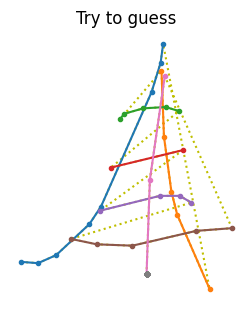

Top-5 predictions:
  1. the eiffel tower 52.061%
  2. ladder 26.590%
  3. leaf 3.866%
  4. feather 1.730%
  5. waterslide 1.344%
Answer: the eiffel tower


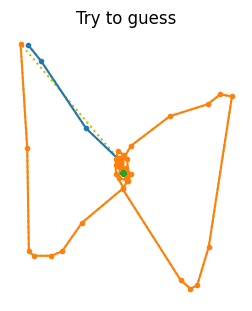

Top-5 predictions:
  1. bowtie 29.990%
  2. fish 11.647%
  3. megaphone 5.205%
  4. shark 4.819%
  5. trumpet 4.596%
Answer: bowtie


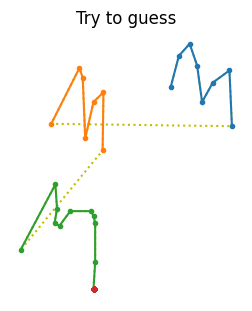

Top-5 predictions:
  1. animal migration 76.337%
  2. ocean 9.898%
  3. squiggle 1.520%
  4. beach 1.079%
  5. moustache 0.806%
Answer: animal migration


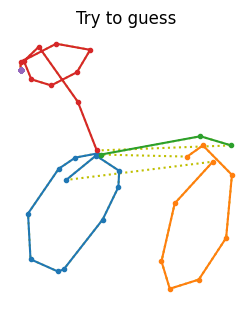

Top-5 predictions:
  1. bicycle 40.398%
  2. motorbike 32.700%
  3. helicopter 11.028%
  4. binoculars 4.266%
  5. scissors 3.132%
Answer: bicycle


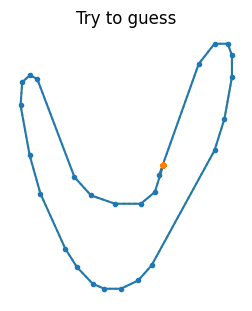

Top-5 predictions:
  1. fish 63.171%
  2. boomerang 10.896%
  3. moustache 4.509%
  4. peanut 1.919%
  5. snake 1.855%
Answer: boomerang


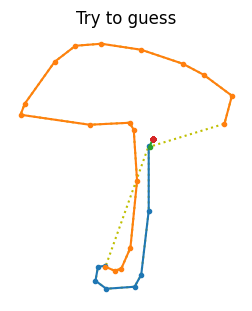

Top-5 predictions:
  1. mushroom 33.960%
  2. umbrella 31.544%
  3. popsicle 9.698%
  4. floor lamp 3.501%
  5. parachute 2.690%
Answer: umbrella


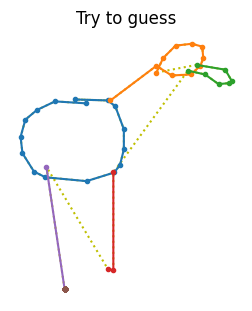

Top-5 predictions:
  1. bird 21.421%
  2. flamingo 12.452%
  3. duck 11.861%
  4. dog 6.795%
  5. parrot 5.450%
Answer: flamingo


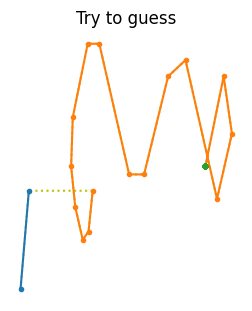

Top-5 predictions:
  1. grass 45.434%
  2. zigzag 18.551%
  3. ocean 15.524%
  4. squiggle 7.899%
  5. mountain 2.103%
Answer: moustache


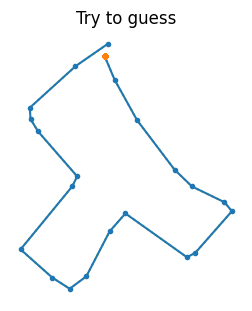

Top-5 predictions:
  1. pliers 19.871%
  2. star 17.892%
  3. crocodile 4.925%
  4. eraser 3.667%
  5. the eiffel tower 3.467%
Answer: octagon


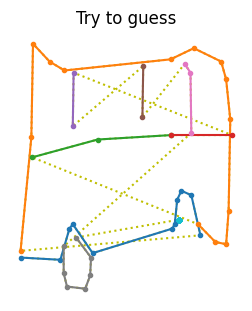

Top-5 predictions:
  1. bus 21.861%
  2. school bus 19.901%
  3. piano 17.892%
  4. couch 11.299%
  5. firetruck 3.930%
Answer: school bus


In [33]:
n_new = 10
Y_probas = model.predict(sketches)
top_k = tf.nn.top_k(Y_probas, k=5)
for index in range(n_new):
    plt.figure(figsize=(3, 3.5))
    draw_sketch(sketches[index])
    plt.show()
    print("Top-5 predictions:".format(index + 1))
    for k in range(5):
        class_name = class_names[top_k.indices[index, k]]
        proba = 100 * top_k.values[index, k]
        print("  {}. {} {:.3f}%".format(k + 1, class_name, proba))
    print("Answer: {}".format(class_names[labels[index].numpy()]))

In [34]:
model.save("my_sketchrnn.keras")